In [1]:
import transformers
import torch

print(transformers.__version__)
print(torch.__version__)
print(torch.cuda.is_available())


5.0.0
2.10.0+cu128
True


In [2]:
!pip install -q transformers datasets evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.3 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from datasets import Dataset

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)

In [6]:
import gdown

url = "https://drive.google.com/file/d/1gND_ylSniEH7F7BTqEpS6QEqdg78Clkh/view?usp=sharing"

gdown.download(url,"df.pkl",fuzzy=True)

df = pd.read_pickle("df.pkl")

Downloading...
From (original): https://drive.google.com/uc?id=1gND_ylSniEH7F7BTqEpS6QEqdg78Clkh
From (redirected): https://drive.google.com/uc?id=1gND_ylSniEH7F7BTqEpS6QEqdg78Clkh&confirm=t&uuid=d5ba2c4d-d420-430f-9cdf-3c696b935cd7
To: /kaggle/working/df.pkl
100%|██████████| 1.22G/1.22G [00:05<00:00, 216MB/s] 


In [7]:
df.head()

,id,target,comment_text,severe_toxicity,obscene,identity_attack,insult,threat,asian,atheist,...,article_id,rating,funny,wow,sad,likes,disagree,sexual_explicit,identity_annotator_count,toxicity_annotator_count
0,59848,0.000000,this is so cool it is like would you want your...,0.000000,0.0,0.000000,0.00000,0.0,NaN,NaN,...,2006,rejected,0,0,0,0,0,0.0,0,4
1,59849,0.000000,thank you this would make my life a lot less a...,0.000000,0.0,0.000000,0.00000,0.0,NaN,NaN,...,2006,rejected,0,0,0,0,0,0.0,0,4
2,59852,0.000000,this is such an urgent design problem kudos to...,0.000000,0.0,0.000000,0.00000,0.0,NaN,NaN,...,2006,rejected,0,0,0,0,0,0.0,0,4
3,59855,0.000000,is this something i will be able to install on...,0.000000,0.0,0.000000,0.00000,0.0,NaN,NaN,...,2006,rejected,0,0,0,0,0,0.0,0,4
4,59856,0.893617,haha you guys are a bunch of losers,0.021277,0.0,0.021277,0.87234,0.0,0.0,0.0,...,2006,rejected,0,0,0,1,0,0.0,4,47


In [8]:
# The raw URL
url = "https://drive.google.com/file/d/1YatDph1Ndo-ETR2o_yOnYLlgtdxqrI01/view?usp=sharing"
output_filename = 'test_df.pkl'

# Use fuzzy=True so gdown strips away the Google HTML warning pages
file_path = gdown.download(url, output_filename, quiet=False, fuzzy=True)

# Read the file now that it is properly saved on disk
test_df = pd.read_pickle(file_path)
test_df.head()

Downloading...
From: https://drive.google.com/uc?id=1YatDph1Ndo-ETR2o_yOnYLlgtdxqrI01
To: /kaggle/working/test_df.pkl
100%|██████████| 29.1M/29.1M [00:00<00:00, 143MB/s] 


,id,comment_text
0,7097320,integrity means that you pay your debts does t...
1,7097321,this is malfeasance by the administrator and t...
2,7097322,rmiller101 spoken like a true elitist but look...
3,7097323,paul thank you for your kind words i do indeed...
4,7097324,sorry you missed high school eisenhower sent t...


In [9]:
df = df[["comment_text","target"]]

In [10]:
df.head()

,comment_text,target
0,this is so cool it is like would you want your...,0.000000
1,thank you this would make my life a lot less a...,0.000000
2,this is such an urgent design problem kudos to...,0.000000
3,is this something i will be able to install on...,0.000000
4,haha you guys are a bunch of losers,0.893617


In [11]:
df["target"] = (
    df["target"] >= 0.5
).astype(int)

In [12]:
df["target"].value_counts()

target
0    1660537
1     144334
Name: count, dtype: int64

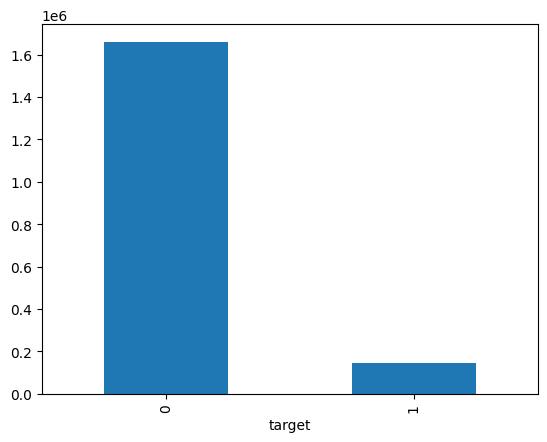

In [21]:
import matplotlib.pyplot as plt

df["target"].value_counts().plot(
    kind="bar"
)
plt.show()

In [13]:
sample_df = df.groupby("target").apply(
    lambda x: x.sample(
        n=min(len(x), 50000),
        random_state=42
    )
).reset_index(drop=True)

/tmp/ipykernel_58/2575127642.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = df.groupby("target").apply(


In [19]:

sample_df["target"].value_counts()

target
0    50000
1    50000
Name: count, dtype: int64

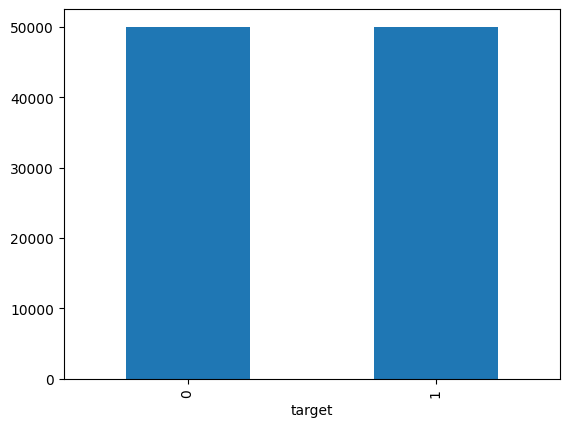

In [20]:
import matplotlib.pyplot as plt

sample_df["target"].value_counts().plot(
    kind="bar"
)
plt.show()

In [22]:
training_args = TrainingArguments(
    output_dir="./results",

    num_train_epochs=1,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    eval_strategy="epoch",

    save_strategy="epoch",

    report_to="none"
)

In [23]:
tokenizer = DistilBertTokenizerFast.from_pretrained(
    "distilbert-base-uncased"
)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [24]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    sample_df["comment_text"],
    sample_df["target"],
    test_size=0.2,
    stratify=sample_df["target"],
    random_state=42
)

In [25]:
train_encodings = tokenizer(
    train_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

val_encodings = tokenizer(
    val_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

In [26]:
print(train_encodings["input_ids"][0])
print(train_encodings["attention_mask"][0])


[101, 2017, 2404, 8398, 1999, 2373, 2219, 2009, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [27]:
train_dataset = Dataset.from_dict({
    "input_ids": train_encodings["input_ids"],
    "attention_mask": train_encodings["attention_mask"],
    "labels": train_labels.tolist()
})

val_dataset = Dataset.from_dict({
    "input_ids": val_encodings["input_ids"],
    "attention_mask": val_encodings["attention_mask"],
    "labels": val_labels.tolist()
})

In [28]:
print(train_dataset[0])

{'input_ids': [101, 2017, 2404, 8398, 1999, 2373, 2219, 2009, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'labels': 0}


In [31]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [33]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="binary"
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

In [34]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

In [35]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.555766,0.536981,0.889450,0.891909,0.872501,0.912200


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2500, training_loss=0.6075048095703125, metrics={'train_runtime': 624.9631, 'train_samples_per_second': 128.008, 'train_steps_per_second': 4.0, 'total_flos': 2649347973120000.0, 'train_loss': 0.6075048095703125, 'epoch': 1.0})

In [36]:
predictions = trainer.predict(val_dataset)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


In [38]:
print(predictions)

PredictionOutput(predictions=array([[-0.9580481 ,  1.1914766 ],
       [ 2.5039556 , -1.7980078 ],
       [ 2.9016774 , -2.1175349 ],
       ...,
       [-1.2319164 ,  1.4322503 ],
       [ 0.39753658, -0.17820115],
       [ 0.7054636 , -0.3966133 ]], shape=(20000, 2), dtype=float32), label_ids=array([1, 0, 0, ..., 1, 0, 0], shape=(20000,)), metrics={'test_loss': 0.5369811654090881, 'test_accuracy': 0.88945, 'test_f1': 0.8919090686873625, 'test_precision': 0.8725011956001913, 'test_recall': 0.9122, 'test_runtime': 50.5951, 'test_samples_per_second': 395.295, 'test_steps_per_second': 12.353})


In [39]:
predictions.predictions.shape

(20000, 2)

In [40]:
preds = np.argmax(
    predictions.predictions,
    axis=1
)

In [42]:
print(preds[:10])

[1 0 0 1 1 0 0 1 0 1]


In [43]:
actual = val_labels.values

for i in range(10):
    print(
        f"Actual: {actual[i]}, Predicted: {preds[i]}"
    )

Actual: 1, Predicted: 1
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 1, Predicted: 1
Actual: 0, Predicted: 1
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 1
Actual: 0, Predicted: 0
Actual: 1, Predicted: 1


In [44]:
print(
    classification_report(
        actual,
        preds
    )
)

              precision    recall  f1-score   support

           0       0.91      0.87      0.89     10000
           1       0.87      0.91      0.89     10000

    accuracy                           0.89     20000
   macro avg       0.89      0.89      0.89     20000
weighted avg       0.89      0.89      0.89     20000



In [45]:
cm = confusion_matrix(
    actual,
    preds
)

print(cm)

[[8667 1333]
 [ 878 9122]]


Testing with user input****

In [53]:
text = "You are an idiot"



In [50]:
import torch
import torch.nn.functional as F

def predict_toxicity(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    # Move inputs to same device as model
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    model.eval()

    with torch.no_grad():
        outputs = model(**inputs)

    probs = F.softmax(outputs.logits, dim=1)

    pred = torch.argmax(probs, dim=1).item()

    return {
        "prediction": pred,
        "non_toxic_prob": probs[0][0].item(),
        "toxic_prob": probs[0][1].item()
    }

In [52]:
predict_toxicity(text)

{'prediction': 1,
 'non_toxic_prob': 0.002463513519614935,
 'toxic_prob': 0.9975365400314331}

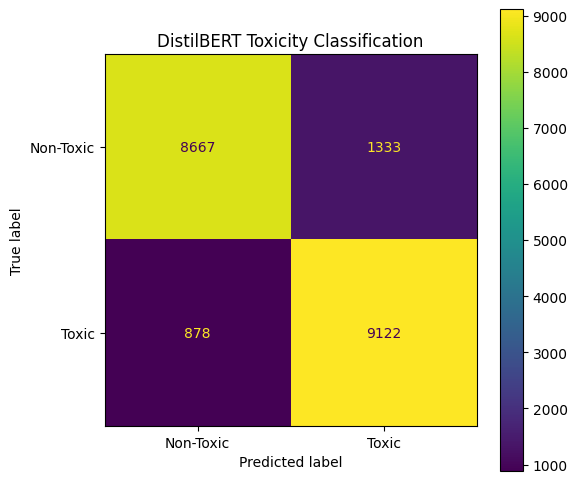

In [55]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(val_labels, preds)

fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Toxic", "Toxic"]
)

disp.plot(ax=ax)

plt.title("DistilBERT Toxicity Classification")
plt.show()

In [59]:
model.eval()

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [60]:
!pip install torchinfo -q

In [61]:
from torchinfo import summary

summary(
    model,
    input_size=(1, 128),
    dtypes=[torch.long]
)

Layer (type:depth-idx)                                  Output Shape              Param #
DistilBertForSequenceClassification                     [1, 2]                    --
├─DistilBertModel: 1-1                                  [1, 128, 768]             --
│    └─Embeddings: 2-1                                  [1, 128, 768]             --
│    │    └─Embedding: 3-1                              [1, 128, 768]             23,440,896
│    │    └─Embedding: 3-2                              [1, 128, 768]             393,216
│    │    └─LayerNorm: 3-3                              [1, 128, 768]             1,536
│    │    └─Dropout: 3-4                                [1, 128, 768]             --
│    └─Transformer: 2-2                                 [1, 128, 768]             --
│    │    └─ModuleList: 3-5                             --                        42,527,232
├─Linear: 1-2                                           [1, 768]                  590,592
├─Dropout: 1-3                 

In [63]:
print(model.config)

DistilBertConfig {
  "activation": "gelu",
  "architectures": [
    "DistilBertForSequenceClassification"
  ],
  "attention_dropout": 0.1,
  "bos_token_id": null,
  "dim": 768,
  "dropout": 0.1,
  "dtype": "float32",
  "eos_token_id": null,
  "hidden_dim": 3072,
  "initializer_range": 0.02,
  "max_position_embeddings": 512,
  "model_type": "distilbert",
  "n_heads": 12,
  "n_layers": 6,
  "pad_token_id": 0,
  "problem_type": "single_label_classification",
  "qa_dropout": 0.1,
  "seq_classif_dropout": 0.2,
  "sinusoidal_pos_embds": false,
  "tie_weights_": true,
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "use_cache": false,
  "vocab_size": 30522
}

